## Simulate data

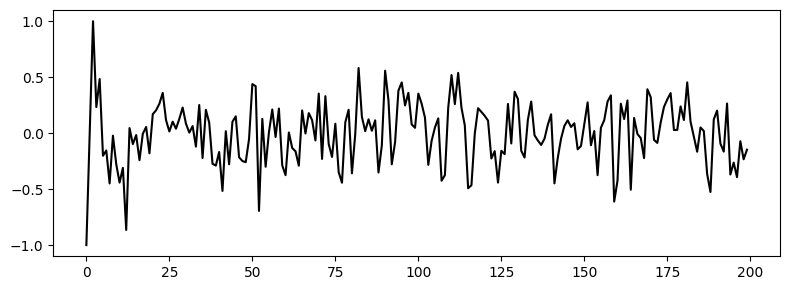

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

T = 200
Y = np.zeros(T)
Y[:3] = np.array([-1, 0, 1])
for t in range(3, T):
    u = np.random.uniform()
    if u <= 0.5:
        loc = 0.1 * Y[t-1] + 0.1 * Y[t-2]
    elif u > 0.8:
        loc = 0.3 * Y[t-1] + 0.5 * Y[t-2]
    else:
        loc = 0.4 * Y[t-1] - 0.5 * Y[t-2]
    Y[t] = np.random.normal(loc=loc, scale=0.25)

_, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(T), Y, c='k')
plt.tight_layout()
plt.show()

## Setting the priors

In [ ]:
p = 2
K = 3

Y = Y[p:]
X = np.zeros((T-p, p))
for i in range(p):
    X[:, i] = Y[p-i-1:T-i-1]
N = len(Y)  # N = T - p

# Hyperparameters
m0 = np.zeros(p)
C0 = 10 * np.eye(p)
invC0 = 0.1 * np.eye(p)
n0 = 1
d0 = 1
a = np.ones(K)

## Sampling functions

In [ ]:
def sample_weights()

## Gibbs sampler

In [3]:
# Initial values
beta = np.zeros(p * K)
L = np.random.choice(K, size=N)
omega = np.ones(K) / K
nu = np.ones(K)

In [6]:
def sample_weights(L: np.ndarray):
    counts = np.bincount(L, minlength=K)
    return np.random.dirichlet(a + counts)

In [9]:
def sample_L(Y: np.ndarray, X: np.ndarray, beta: np.ndarray, omega: np.ndarray, nu: np.ndarray):
    log_probs = np.zeros((N, K))
    for k in range(K):
        beta_k = beta[k*p:(k+1)*p]
        loc = X @ beta_k
        log_probs[:, k] = np.log(omega[k]) - 0.5 * np.log(nu[k]) - 0.5 * (Y - loc)**2 / nu[k]
    log_probs -= log_probs.max(axis=1, keepdims=True)
    probs = np.exp(log_probs)
    probs /= probs.sum(axis=1, keepdims=True)
    return np.array([np.random.choice(K, p=probs[i]) for i in range(N)])

In [7]:
omega_new = sample_weights(L)
print(omega_new)

[0.35498336 0.28968468 0.35533195]


In [10]:
L_new = sample_L(Y, X, beta, omega_new, nu)

In [ ]:
def sample_nu(k, L):
    idx = (L == k)
    n_k = idx.sum()
    if n_k < 5:
        n_k_star = n0
        d_k_star = d0
    else:
        y_tilde_k = Y[idx]
        X_tilde_k = X[idx]
        e_k = y_tilde_k - X_tilde_k @ m0
        Q_k = X_tilde_k.T @ C0 @ X_tilde_k + np.eye(n_k)
        A_k = C0 @ X_tilde_k @ np.linalg.inv(Q_k)
        m_k = m0 + A_k @ e_k
        C_k = C0 - A_k @ Q_k @ A_k.T
        n_k_star = n0 + n_k
        d_k_star = d0 + (e_k.T @ np.linalg.inv(Q_k) @ e_k)